### Imports and audio file display

In [128]:
import torch as tor
import torchaudio as tad
import matplotlib.pyplot as plt
import noisereduce as nod

from IPython.display import Audio
from glob import glob

In [129]:
audio = glob(pathname=r"C:\Users\Admin\Documents\Mirage-Omega1\ml_models\ete_synthesis\audios\*")

In [130]:
Audio(audio[0]) # mysterious Audio file

### Processing Now

In [131]:
y, sr = tad.load(audio[0], channels_first=True)

In [132]:
y, sr

(tensor([[ 0.0000,  0.0000,  0.0000,  ..., -0.0045, -0.0060, -0.0078]]), 16000)

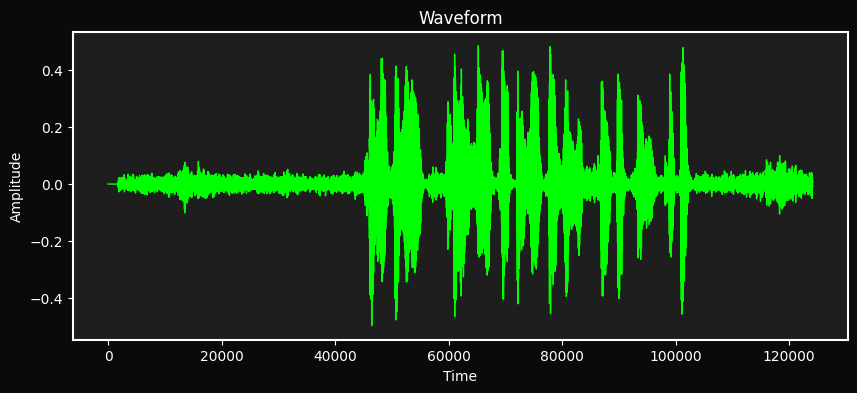

In [154]:
fig = plt.figure(figsize=(10, 4), facecolor="#0a0a0a")  # Dark background overall
ax = fig.add_subplot(1, 1, 1)

ax.set_facecolor("#1e1e1e")  # Slightly different color for plot area
ax.plot(y.t().numpy(), color='lime', lw=1)

ax.set_title("Waveform", color='white')
ax.set_xlabel("Time", color='white')
ax.set_ylabel("Amplitude", color='white')
ax.tick_params(colors='white')

# 🔥 Make border visible
for spine in ax.spines.values():
    spine.set_color('white')
    spine.set_linewidth(1.5)

plt.show()

In [ ]:
# normalize audio
normalized_y = y / y.abs().max()

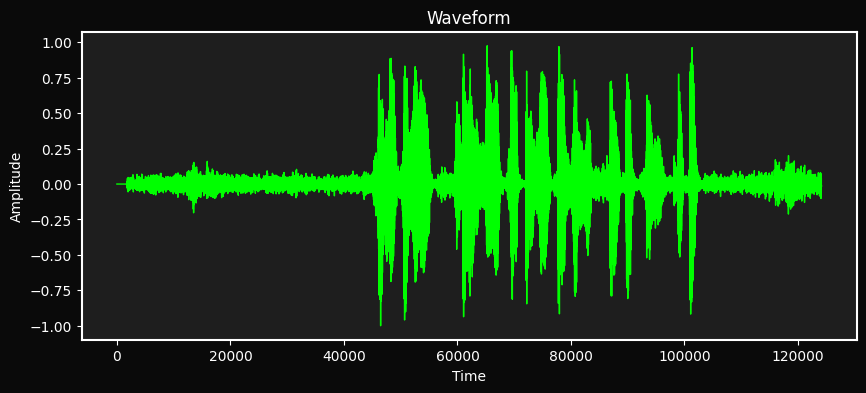

In [135]:
fig = plt.figure(figsize=(10, 4), facecolor="#0a0a0a")  # Dark background overall
ax = fig.add_subplot(1, 1, 1)

ax.set_facecolor("#1e1e1e")  # Slightly different color for plot area
ax.plot(normalized_y.t().numpy(), color='lime', lw=1)

# ax.set_ylim(-1.5, 1.0)
ax.set_title("Waveform", color='white')
ax.set_xlabel("Time", color='white')
ax.set_ylabel("Amplitude", color='white')
ax.tick_params(colors='white')

# 🔥 Make border visible
for spine in ax.spines.values():
    spine.set_color('white')
    spine.set_linewidth(1.5)

plt.show()

In [136]:
Audio(normalized_y.numpy(), rate=sr)

In [ ]:
denoised = nod.reduce_noise(normalized_y, sr=sr, prop_decrease=0.98)

In [ ]:
denoised = denoised.mean(axis=0)

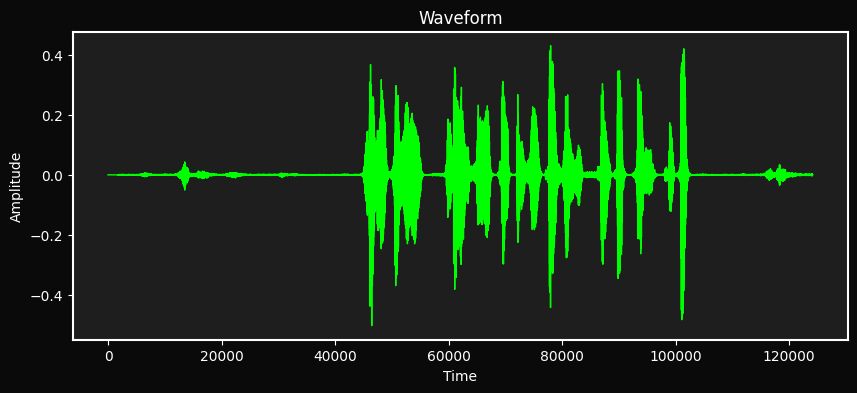

In [139]:
fig = plt.figure(figsize=(10, 4), facecolor="#0a0a0a")  # Dark background overall
ax = fig.add_subplot(1, 1, 1)

ax.set_facecolor("#1e1e1e")  # Slightly different color for plot area
ax.plot(denoised, color='lime', lw=1)

ax.set_title("Waveform", color='white')
ax.set_xlabel("Time", color='white')
ax.set_ylabel("Amplitude", color='white')
ax.tick_params(colors='white')

# 🔥 Make border visible
for spine in ax.spines.values():
    spine.set_color('white')
    spine.set_linewidth(1.5)

plt.show()

In [140]:
Audio(denoised, rate=sr)

In [141]:
denoised_tenor = tor.tensor(denoised).unsqueeze(0)

In [ ]:
trimmed_y = tad.transforms.Vad(sr)(denoised_tenor.clone().detach())

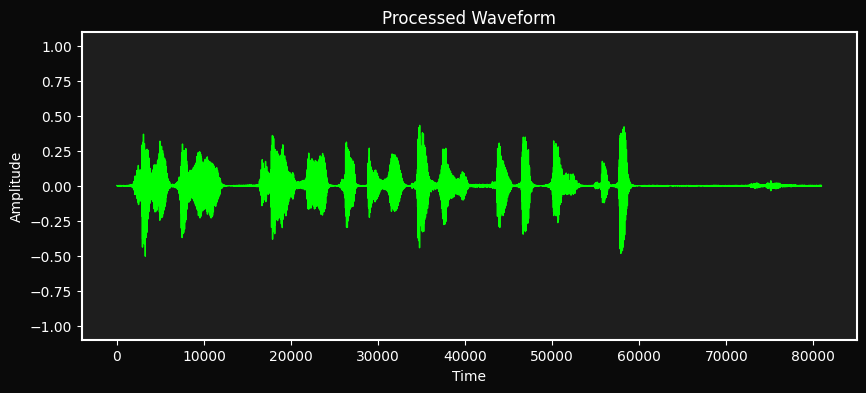

In [143]:
fig = plt.figure(figsize=(10, 4), facecolor="#0a0a0a")
ax = fig.add_subplot(1, 1, 1)
ax.set_facecolor("#1e1e1e")
ax.plot(trimmed_y.squeeze().numpy(), color='lime', lw=1)

ax.set_ylim(-1.1, 1.1)
ax.set_title("Processed Waveform", color='white')
ax.set_xlabel("Time", color='white')
ax.set_ylabel("Amplitude", color='white')
ax.tick_params(colors='white')

# Make border visible
for spine in ax.spines.values():
    spine.set_color('white')
    spine.set_linewidth(1.5)

plt.show()

In [ ]:
mono = tor.mean(trimmed_y, dim=0, keepdim=True)

In [ ]:
resampled_audio = tad.functional.resample(mono, orig_freq=sr, new_freq=22050)

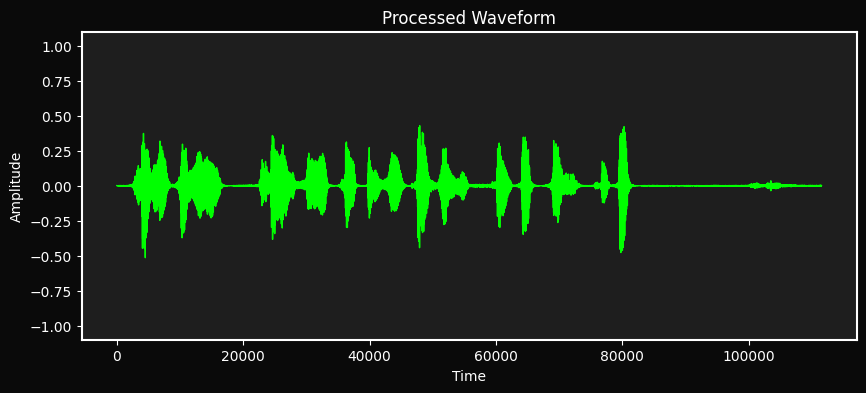

In [146]:
fig = plt.figure(figsize=(10, 4), facecolor="#0a0a0a")
ax = fig.add_subplot(1, 1, 1)
ax.set_facecolor("#1e1e1e")
ax.plot(resampled_audio.squeeze().numpy(), color='lime', lw=1)

ax.set_ylim(-1.1, 1.1)
ax.set_title("Processed Waveform", color='white')
ax.set_xlabel("Time", color='white')
ax.set_ylabel("Amplitude", color='white')
ax.tick_params(colors='white')

# Make border visible
for spine in ax.spines.values():
    spine.set_color('white')
    spine.set_linewidth(1.5)

plt.show()

In [147]:
resampled_audio = resampled_audio.squeeze().numpy()
display(Audio(resampled_audio, rate=22050))

In [148]:
resampled_audio

array([ 0.00056009,  0.00052211,  0.00031267, ...,  0.00013981,
       -0.00017351, -0.00018134], dtype=float32)

In [155]:
import torchaudio.functional as F

filtered_waveform = F.equalizer_biquad(
    tor.tensor(resampled_audio), sample_rate=22050, center_freq=1000, gain=10.0, Q=0.707
)


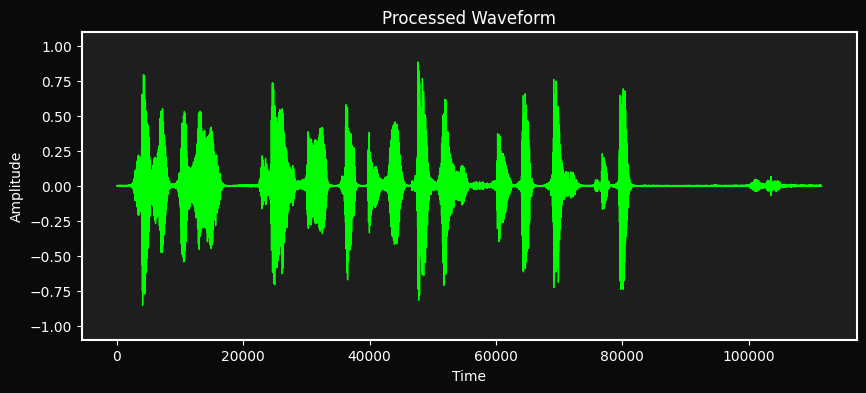

In [156]:
fig = plt.figure(figsize=(10, 4), facecolor="#0a0a0a")
ax = fig.add_subplot(1, 1, 1)
ax.set_facecolor("#1e1e1e")
ax.plot(filtered_waveform.squeeze().numpy(), color='lime', lw=1)

ax.set_ylim(-1.1, 1.1)
ax.set_title("Processed Waveform", color='white')
ax.set_xlabel("Time", color='white')
ax.set_ylabel("Amplitude", color='white')
ax.tick_params(colors='white')

# Make border visible
for spine in ax.spines.values():
    spine.set_color('white')
    spine.set_linewidth(1.5)

plt.show()

In [208]:
Audio(filtered_waveform, rate=22050)

In [178]:
filtered_waveform

tensor([ 0.0007,  0.0008,  0.0007,  ...,  0.0002, -0.0001, -0.0002])

In [185]:
filtered_waveform = filtered_waveform.clone().detach().unsqueeze(dim=0)


In [ ]:
tad.save("new.wav", filtered_waveform, sample_rate=22050)